In [1]:
import pandas as pd
df = pd.read_csv('final_data_physics_baseline/phy_final_corrected_data.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')
df.drop(columns= 'Unnamed: 0', inplace= True)
df.drop(columns= 'Unnamed: 0.1', inplace= True)

# we convert 0-12 to radians circle for a seasonal mapping (circular time encoding)
# ensure index is treated as datetime (works even if the Index is not recognized as DatetimeIndex)
import numpy as np
month = pd.DatetimeIndex(df.index).month

df['year_sin'] = np.sin(2*np.pi*month/12)
df['year_cos'] = np.cos(2*np.pi*month/12)


df1 = df.copy()
df.head()


,dewpoint,et_loss,ndvi,precipitation,radiation,sca,dd,temp,runoff,year_sin,year_cos
date,,,,,,,,,,,
2000-06-30,270.274111,0.035384,0.167895,1.081265,8552.215167,15695.091988,0.000000,255.924696,0.959289,1.224647e-16,-1.000000e+00
2000-07-31,275.634907,0.005471,0.214835,2.074423,8945.476526,6188.434963,0.000000,253.865719,0.515886,-5.000000e-01,-8.660254e-01
2000-08-31,273.643363,0.016486,0.171795,1.208544,8787.250911,10114.130241,0.000000,258.913569,0.355015,-8.660254e-01,-5.000000e-01
2000-09-30,266.780844,0.040531,0.148384,0.857759,7687.016192,12888.810599,0.000000,265.094486,0.186357,-1.000000e+00,-1.836970e-16
2000-10-31,259.412862,0.029951,0.113129,0.231264,5685.865842,19583.623736,0.551964,273.551964,0.138155,-8.660254e-01,5.000000e-01


In [2]:
import sktime

(<Figure size 1600x400 with 1 Axes>, <Axes: ylabel='runoff'>)

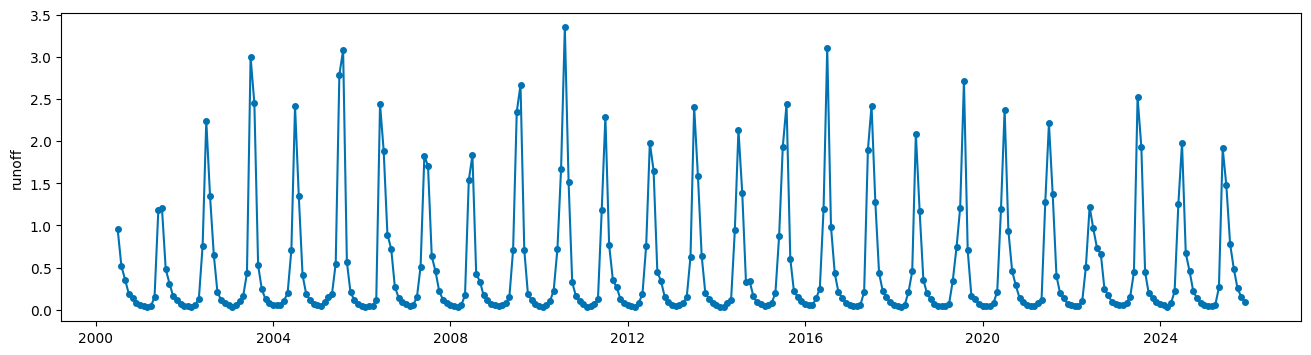

In [3]:
from sktime.utils.plotting import plot_series

y = df1['runoff']

# plotting for visualization
plot_series(y)

In [4]:
y.index

DatetimeIndex(['2000-06-30', '2000-07-31', '2000-08-31', '2000-09-30',
               '2000-10-31', '2000-11-30', '2000-12-31', '2001-01-31',
               '2001-02-28', '2001-03-31',
               ...
               '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31',
               '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30',
               '2025-10-31', '2025-11-30'],
              dtype='datetime64[ns]', length=306, freq=None)

In [5]:
y = df1['runoff']   # target
X = df1[['sca', 'dd', 'precipitation', 'et_loss']]  # raw features only

In [6]:
y.index

DatetimeIndex(['2000-06-30', '2000-07-31', '2000-08-31', '2000-09-30',
               '2000-10-31', '2000-11-30', '2000-12-31', '2001-01-31',
               '2001-02-28', '2001-03-31',
               ...
               '2025-02-28', '2025-03-31', '2025-04-30', '2025-05-31',
               '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30',
               '2025-10-31', '2025-11-30'],
              dtype='datetime64[ns]', length=306, freq=None)

In [7]:
from sktime.forecasting.model_selection import temporal_train_test_split

y_train, y_test, X_train, X_test = temporal_train_test_split(
    y, X, test_size = 0.2
)

In [8]:
from sktime.forecasting.arima import AutoARIMA

forecaster = AutoARIMA(
    seasonal=True,
    m=12,   # monthly data
    suppress_warnings=True
)

TypeError: AutoARIMA.__init__() got an unexpected keyword argument 'm'

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    index=X.index,
    columns=X.columns
)

In [10]:
from sktime.forecasting.ets import AutoETS

forecaster = AutoETS(
    seasonal='add',
    sp=12
)

In [11]:
forecaster.fit(y_train)

/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: divide by zero encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: overflow encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: invalid value encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],


AutoETS(seasonal='add', sp=12)

In [12]:
fh = list(range(1, len(y_test)+1))

y_pred = forecaster.predict(fh=fh, X=X_test)

y_pred = forecaster.predict(fh=fh, X=X_test)
print(fh)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62]


/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  absolute = pd.DatetimeIndex(absolute, freq=fh.freq)
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sktime/forecasting/base/_fh.py:877: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME'

In [13]:
from utils import calculate_nse
print(calculate_nse(y_test.values, y_pred.values))

0.7686271849235883


In [14]:
import numpy as np

def nse(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)

print(nse(y_test.values, y_pred.values))

0.7686271849235883


In [15]:
import warnings

In [16]:
from sktime.forecasting.model_selection import ExpandingWindowSplitter
from sktime.forecasting.model_evaluation import evaluate
from sktime.performance_metrics.forecasting import make_forecasting_scorer
# nse_scorer = make_forecasting_scorer(nse)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)
 
cv = ExpandingWindowSplitter(
    initial_window=int(len(y)*0.6),
    step_length=12,
    fh = [1,2,3,4,5,6]
)
nse_scorer = make_forecasting_scorer(
    nse,
    name="nse",
    greater_is_better=True
)
results = evaluate(
    forecaster,
    y=y,
    X=X,
    cv=cv,
    strategy="refit",
    scoring=nse_scorer,
    error_score='raise'
)
# print(results)
print(results['test_nse'].mean())
# print(results.columns)
# print(results['test_nse'])
print(results[['test_nse', 'len_train_window', 'cutoff']])
print(results['test_nse'].std())
print(results['test_nse'].median())

/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: divide by zero encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: overflow encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: invalid value encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisen

0.9107922436062758
   test_nse  len_train_window     cutoff
0  0.913371               183 2015-08-31
1  0.969706               195 2016-08-31
2  0.972739               207 2017-08-31
3  0.899731               219 2018-08-31
4  0.706619               231 2019-08-31
5  0.907244               243 2020-08-31
6  0.916793               255 2021-08-31
7  0.925643               267 2022-08-31
8  0.897520               279 2023-08-31
9  0.998558               291 2024-08-31
0.07977211775461156
0.9150818401592539


/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: divide by zero encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: overflow encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/statsmodels/tools/tools.py:274: RuntimeWarning: invalid value encountered in dot
  res = np.dot(np.transpose(vt), np.multiply(s[:, np.newaxis],
/Users/abhimanyu/Desktop/projects/the_indus_project/gisenv/lib/python3.13/site-packages/sktime/forecasting/base/_fh.py:863: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return r * to_offset(fh.freq)
/Users/abhimanyu/Desktop/projects/the_indus_project/g

In [17]:
residuals = y_test - y_pred

In [ ]:
from clean_model_steps import df_adv
